<a href="https://colab.research.google.com/github/nisha-s10/Deep-Learning-Lab-AFI524/blob/main/Experiment%209/Experiment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1 — Install Libraries

In [ ]:
!pip install wandb
!pip install huggingface_hub

### Step 2 — Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import os

import wandb
from huggingface_hub import login, create_repo, upload_file

### Step 3 — Device Setup

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


### Step 4 — Initialize Weights & Biases

In [ ]:
# wandb.init(
#     project="GAN-FashionMNIST",
#     config={
#         "epochs": 10,
#         "batch_size": 128,
#         "learning_rate": 0.0002,
#         "latent_dim": 100
#     }
# )

wandb.init(
    project="Experiment-9-GAN-DCGAN",
    mode="offline"
)

### Step 5 — Data Preprocessing (IMPORTANT: [-1, 1])

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

### Step 6 — DataLoader

In [ ]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

### Step 7 — Hyperparameters

In [ ]:
latent_dim = 100
epochs = 10
lr = 0.0002

### Step 8 — Vanilla GAN Generator

In [ ]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):

        img = self.model(z)

        img = img.view(
            z.size(0),
            1,
            28,
            28
        )

        return img

### Step 9 — Vanilla GAN Discriminator

In [ ]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):

        img = img.view(
            img.size(0),
            -1
        )

        validity = self.model(img)

        return validity

### Step 10 — Initialize Models

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

print("Models initialized")

Models initialized


### Step 11 — Loss Function (BCE Baseline)

In [ ]:
adversarial_loss = nn.BCELoss()

### Step 12 — Optimizers (Adam Baseline)

In [ ]:
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=lr
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=lr
)

### Step 13 — Function to Save Generated Images

In [ ]:
def save_images(images, epoch):

    images = images[:25]

    grid = torchvision.utils.make_grid(
        images,
        nrow=5,
        normalize=True
    )

    np_grid = grid.cpu().numpy()

    plt.imshow(
        np.transpose(np_grid, (1, 2, 0))
    )

    plt.title(f"Epoch {epoch}")

    plt.axis("off")

    plt.show()

### Step 14 — GAN Training Loop

Epoch 1 | D Loss: 0.2705 | G Loss: 1.6364


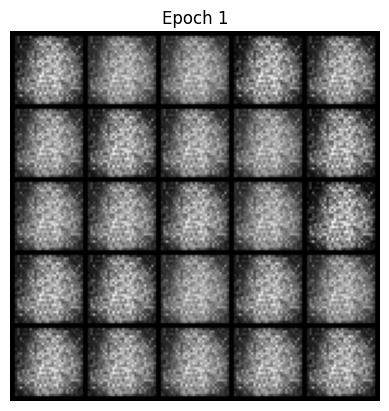

Epoch 2 | D Loss: 0.0065 | G Loss: 5.1593


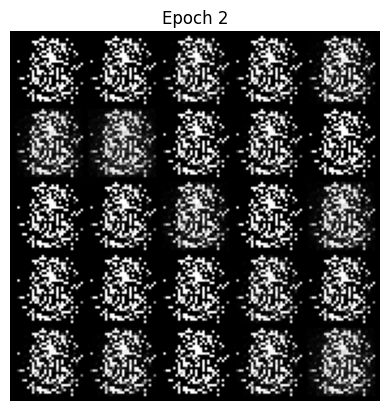

Epoch 3 | D Loss: 0.0676 | G Loss: 3.4215


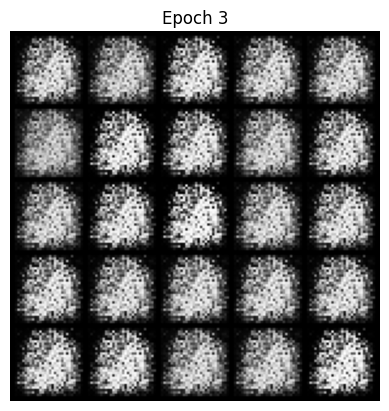

Epoch 4 | D Loss: 0.0137 | G Loss: 4.6665


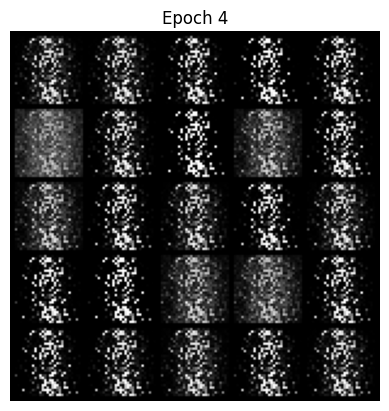

Epoch 5 | D Loss: 0.0370 | G Loss: 4.7966


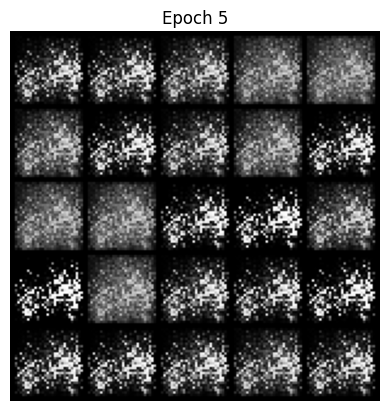

Epoch 6 | D Loss: 0.0948 | G Loss: 3.5003


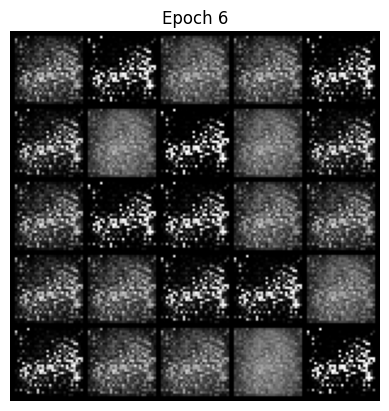

Epoch 7 | D Loss: 0.0916 | G Loss: 4.8320


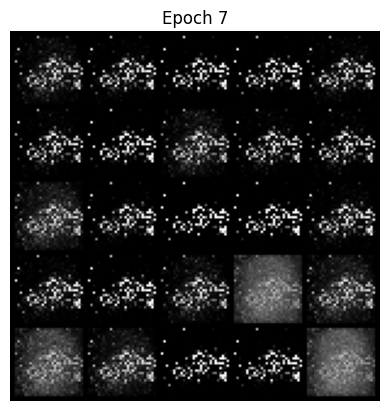

Epoch 8 | D Loss: 0.1140 | G Loss: 4.0644


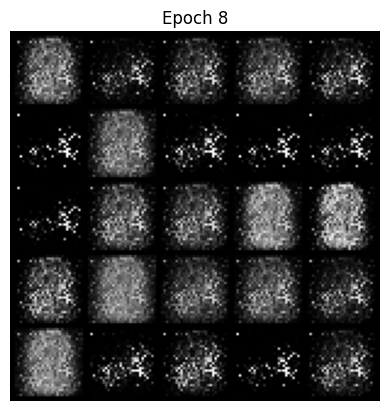

Epoch 9 | D Loss: 0.0952 | G Loss: 2.4924


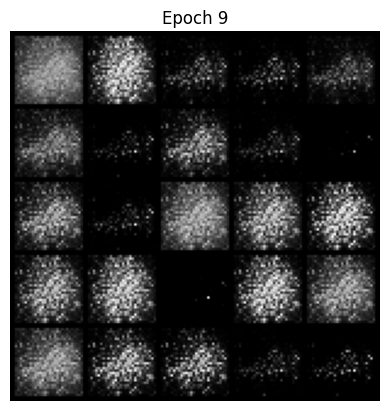

Epoch 10 | D Loss: 0.1074 | G Loss: 3.6650


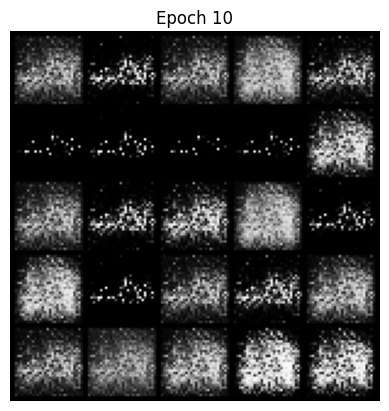

In [ ]:
# Initialize loss history

loss_history = {

    "Generator": [],

    "Discriminator": []

}

for epoch in range(epochs):

    for i, (imgs, _) in enumerate(train_loader):

        real_imgs = imgs.to(device)

        valid = torch.ones(
            imgs.size(0),
            1
        ).to(device)

        fake = torch.zeros(
            imgs.size(0),
            1
        ).to(device)

        # -------------------------
        # Train Generator
        # -------------------------

        optimizer_G.zero_grad()

        z = torch.randn(
            imgs.size(0),
            latent_dim
        ).to(device)

        gen_imgs = generator(z)

        g_loss = adversarial_loss(
            discriminator(gen_imgs),
            valid
        )

        g_loss.backward()

        optimizer_G.step()

        # -------------------------
        # Train Discriminator
        # -------------------------

        optimizer_D.zero_grad()

        real_loss = adversarial_loss(
            discriminator(real_imgs),
            valid
        )

        fake_loss = adversarial_loss(
            discriminator(gen_imgs.detach()),
            fake
        )

        d_loss = (
            real_loss + fake_loss
        ) / 2

        d_loss.backward()

        optimizer_D.step()

        # -------------------------
        # Store losses
        # -------------------------

        loss_history["Generator"].append(
            g_loss.item()
        )

        loss_history["Discriminator"].append(
            d_loss.item()
        )

    print(
        f"Epoch {epoch+1} | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

    wandb.log({
        "Generator Loss": g_loss.item(),
        "Discriminator Loss": d_loss.item()
    })

    save_images(gen_imgs, epoch+1)

### Step 15 — Save Generator Model

In [ ]:
os.makedirs(
    "models",
    exist_ok=True
)

torch.save(
    generator.state_dict(),
    "models/generator.pth"
)

print("Model saved")

Model saved


### Step 16 — Login to Hugging Face

In [ ]:
login()

### Step 17 — Create Hugging Face Repository

In [ ]:
create_repo(
    repo_id="nishas3/experiment-9-gan-dcgan",
    repo_type="model",
    exist_ok=True
)

RepoUrl('https://huggingface.co/nishas3/experiment-9-gan-dcgan', endpoint='https://huggingface.co', repo_type='model', repo_id='nishas3/experiment-9-gan-dcgan')

### Step 18 —Upload Model to Hugging Face

In [ ]:
upload_file(
    path_or_fileobj="models/generator.pth",
    path_in_repo="generator.pth",
    repo_id="nishas3/experiment-9-gan-dcgan",
    repo_type="model"
)

print("Model uploaded to Hugging Face")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model uploaded to Hugging Face


### Step 19 — Plot Loss Curves

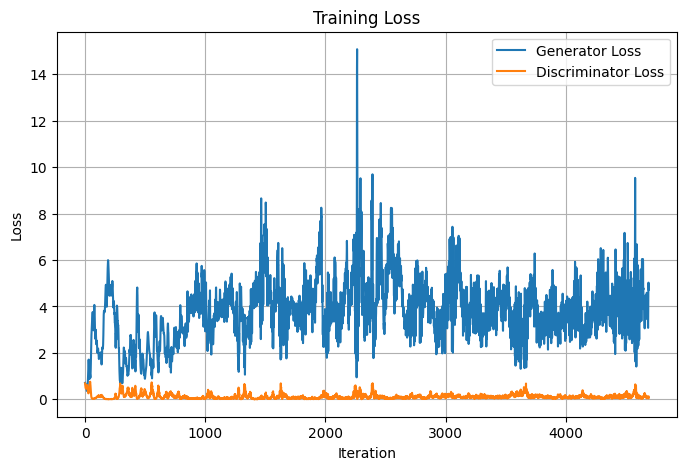

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    loss_history["Generator"],
    label="Generator Loss"
)

plt.plot(
    loss_history["Discriminator"],
    label="Discriminator Loss"
)

plt.title("Training Loss")

plt.xlabel("Iteration")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### Step 20 — DCGAN Generator

In [ ]:
class DCGenerator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(
                latent_dim,
                128,
                7,
                1,
                0
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                1,
                4,
                2,
                1
            ),

            nn.Tanh()
        )

    def forward(self, z):

        z = z.view(
            z.size(0),
            latent_dim,
            1,
            1
        )

        img = self.model(z)

        return img

### Step 21 — DCGAN Discriminator

In [ ]:
class DCDiscriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1,
                64,
                4,
                2,
                1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Flatten(),

            nn.Linear(
                128 * 7 * 7,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, img):

        return self.model(img)

### Step 22 — Initialize DCGAN Models

In [ ]:
dc_generator = DCGenerator().to(device)

dc_discriminator = DCDiscriminator().to(device)

print("DCGAN models initialized")

DCGAN models initialized


### Step 23 — Additional Loss Functions

#### LSGAN Loss

In [ ]:
def lsgan_loss(prediction, target):

    return torch.mean(
        (prediction - target) ** 2
    )

#### WGAN Loss

In [ ]:
def wgan_loss(prediction, target):

    return -torch.mean(
        prediction * target
    )

### Step 24 — Additional Optimizers

In [ ]:
optimizers = {

    "SGD": optim.SGD,

    "RMSprop": optim.RMSprop,

    "Adam": optim.Adam

}

### Step 25 — Training Function Supporting All Variants

In [ ]:
def train_gan(

    generator,
    discriminator,
    loss_fn,
    optimizer_name,
    model_name

):

    optimizer_G = optimizers[
        optimizer_name
    ](
        generator.parameters(),
        lr=0.0002
    )

    optimizer_D = optimizers[
        optimizer_name
    ](
        discriminator.parameters(),
        lr=0.0002
    )

    for epoch in range(5):

        for imgs, _ in train_loader:

            real_imgs = imgs.to(device)

            valid = torch.ones(
                imgs.size(0),
                1
            ).to(device)

            fake = torch.zeros(
                imgs.size(0),
                1
            ).to(device)

            # Train Generator

            optimizer_G.zero_grad()

            z = torch.randn(
                imgs.size(0),
                latent_dim
            ).to(device)

            gen_imgs = generator(z)

            g_loss = loss_fn(

                discriminator(gen_imgs),

                valid

            )

            g_loss.backward()

            optimizer_G.step()

            # Train Discriminator

            optimizer_D.zero_grad()

            real_loss = loss_fn(

                discriminator(real_imgs),

                valid

            )

            fake_loss = loss_fn(

                discriminator(

                    gen_imgs.detach()

                ),

                fake

            )

            d_loss = (

                real_loss +

                fake_loss

            ) / 2

            d_loss.backward()

            optimizer_D.step()

        print(

            model_name,

            optimizer_name,

            "Epoch",

            epoch + 1,

            "G:",

            g_loss.item(),

            "D:",

            d_loss.item()

        )

        wandb.log({

            "Model": model_name,

            "Optimizer": optimizer_name,

            "Generator Loss": g_loss.item(),

            "Discriminator Loss": d_loss.item()

        })

    return generator

### Step 26 — Train All Required Configurations

In [ ]:
loss_functions = {

    "BCE": adversarial_loss,

    "LSGAN": lsgan_loss,

    "WGAN": lsgan_loss

}

trained_generators = {}

for loss_name, loss_fn in loss_functions.items():

    for opt_name in optimizers:

        print(

            "\nTraining Vanilla GAN",

            loss_name,

            opt_name

        )

        gen = Generator().to(device)

        disc = Discriminator().to(device)

        trained_generators[
            f"Vanilla-{loss_name}-{opt_name}"
        ] = train_gan(

            gen,

            disc,

            loss_fn,

            opt_name,

            "Vanilla GAN"

        )

        print(

            "\nTraining DCGAN",

            loss_name,

            opt_name

        )

        gen = DCGenerator().to(device)

        disc = DCDiscriminator().to(device)

        trained_generators[
            f"DCGAN-{loss_name}-{opt_name}"
        ] = train_gan(

            gen,

            disc,

            loss_fn,

            opt_name,

            "DCGAN"

        )


Training Vanilla GAN BCE SGD
Vanilla GAN SGD Epoch 1 G: 0.7091537117958069 D: 0.6228100061416626
Vanilla GAN SGD Epoch 2 G: 0.7081303596496582 D: 0.5583348274230957
Vanilla GAN SGD Epoch 3 G: 0.7096168398857117 D: 0.507148027420044
Vanilla GAN SGD Epoch 4 G: 0.7126356959342957 D: 0.46354353427886963
Vanilla GAN SGD Epoch 5 G: 0.7173741459846497 D: 0.43161439895629883

Training DCGAN BCE SGD
DCGAN SGD Epoch 1 G: 1.5490893125534058 D: 0.2070043683052063
DCGAN SGD Epoch 2 G: 1.6231756210327148 D: 0.21477751433849335
DCGAN SGD Epoch 3 G: 1.4390562772750854 D: 0.2931273579597473
DCGAN SGD Epoch 4 G: 1.553932547569275 D: 0.2529306709766388
DCGAN SGD Epoch 5 G: 1.465103030204773 D: 0.3276211619377136

Training Vanilla GAN BCE RMSprop
Vanilla GAN RMSprop Epoch 1 G: 0.45747891068458557 D: 0.5766913890838623
Vanilla GAN RMSprop Epoch 2 G: 4.134608268737793 D: 0.260263592004776
Vanilla GAN RMSprop Epoch 3 G: 0.7272515296936035 D: 0.4686192572116852
Vanilla GAN RMSprop Epoch 4 G: 3.69402241706848

### Step 27 — Save All Models

In [ ]:
os.makedirs(
    "models",
    exist_ok=True
)

for name, model in trained_generators.items():

    path = f"models/{name}.pth"

    torch.save(

        model.state_dict(),

        path

    )

print("All models saved")

All models saved


### Step 28 — Upload All Models

In [ ]:
repo_id = "nishas3/experiment-9-gan-dcgan"

create_repo(

    repo_id=repo_id,

    repo_type="model",

    exist_ok=True

)

for file in os.listdir("models"):

    upload_file(

        path_or_fileobj=f"models/{file}",

        path_in_repo=file,

        repo_id=repo_id,

        repo_type="model"

    )

print("All models uploaded to Hugging Face")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


All models uploaded to Hugging Face


### Step 29 — Generate Sample Images for Evaluation

In [ ]:
def generate_samples(generator, title):

    generator.eval()

    with torch.no_grad():

        z = torch.randn(
            25,
            latent_dim
        ).to(device)

        images = generator(z)

    grid = torchvision.utils.make_grid(
        images,
        nrow=5,
        normalize=True
    )

    plt.figure(figsize=(6,6))

    plt.imshow(
        grid.cpu().permute(1,2,0)
    )

    plt.title(title)

    plt.axis("off")

    plt.show()

### Step 30 — Compare Vanilla GAN vs DCGAN

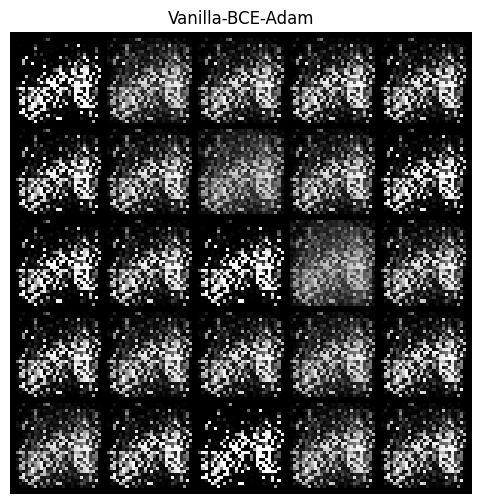

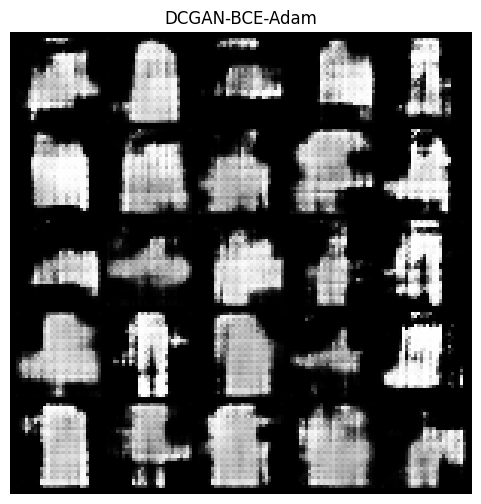

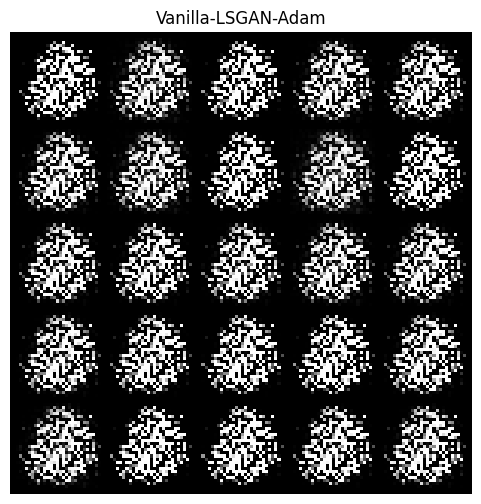

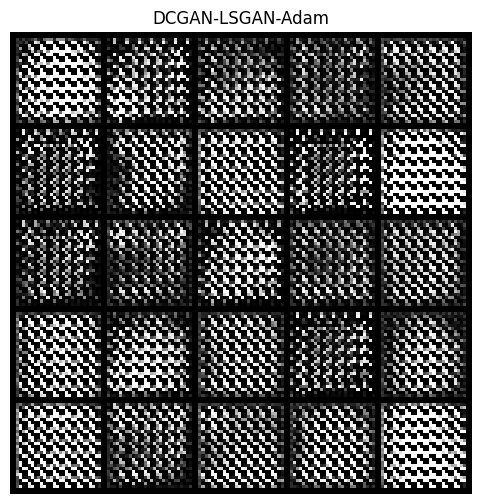

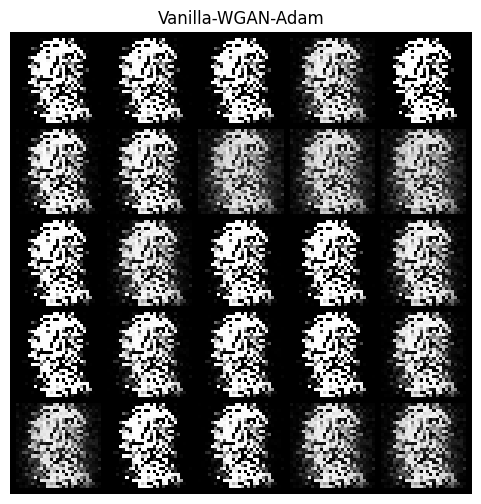

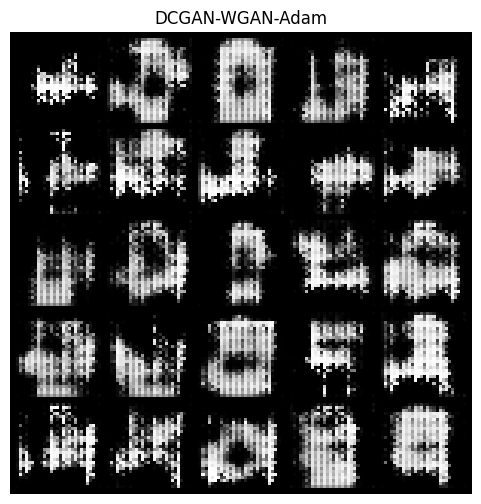

In [ ]:
for name in trained_generators:

    if "Adam" in name:

        generate_samples(

            trained_generators[name],

            title=name

        )

### Step 31 — Diversity Evaluation

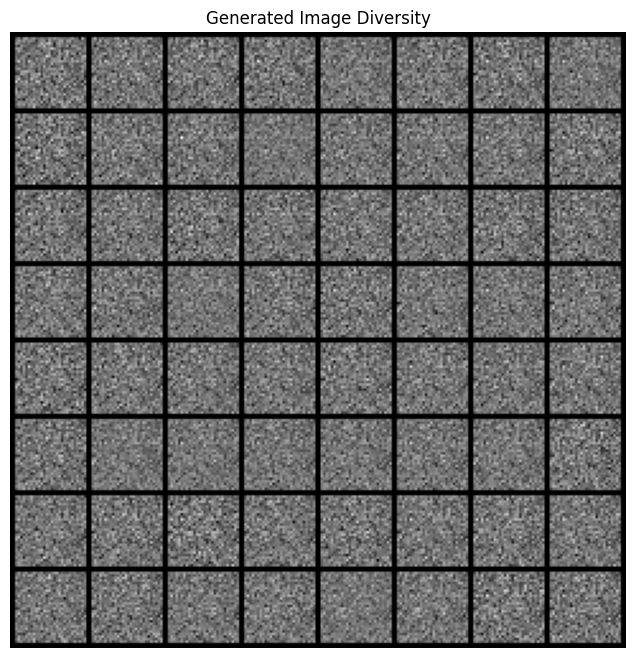

In [ ]:
generator = list(
    trained_generators.values()
)[0]

generator.eval()

with torch.no_grad():

    z = torch.randn(
        64,
        latent_dim
    ).to(device)

    images = generator(z)

grid = torchvision.utils.make_grid(
    images,
    nrow=8,
    normalize=True
)

plt.figure(figsize=(8,8))

plt.imshow(
    grid.cpu().permute(1,2,0)
)

plt.title("Generated Image Diversity")

plt.axis("off")

plt.show()

### Step 32 — Training Stability Comparison

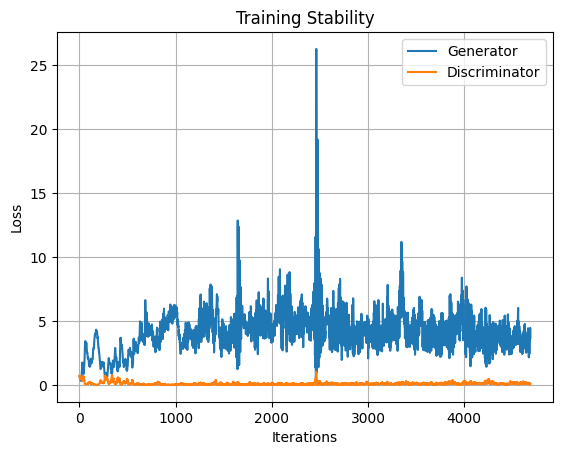

In [ ]:
plt.figure()

plt.plot(
    loss_history["Generator"],
    label="Generator"
)

plt.plot(
    loss_history["Discriminator"],
    label="Discriminator"
)

plt.title("Training Stability")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### Step 33 — Log Evaluation Images to Weights & Biases

In [ ]:
import numpy as np

wandb.log({
    "Generated Samples":
        wandb.Image(
            grid.cpu()
            .permute(1, 2, 0)
            .numpy()
        )
})

### Step 34 — Final Model Summary Print

In [ ]:
print("\nExperiment 9 Completed Successfully")

print("\nModels trained:")

for name in trained_generators:

    print(name)

print("\nTotal models:")

print(len(trained_generators))


Experiment 9 Completed Successfully

Models trained:
Vanilla-BCE-SGD
DCGAN-BCE-SGD
Vanilla-BCE-RMSprop
DCGAN-BCE-RMSprop
Vanilla-BCE-Adam
DCGAN-BCE-Adam
Vanilla-LSGAN-SGD
DCGAN-LSGAN-SGD
Vanilla-LSGAN-RMSprop
DCGAN-LSGAN-RMSprop
Vanilla-LSGAN-Adam
DCGAN-LSGAN-Adam
Vanilla-WGAN-SGD
DCGAN-WGAN-SGD
Vanilla-WGAN-RMSprop
DCGAN-WGAN-RMSprop
Vanilla-WGAN-Adam
DCGAN-WGAN-Adam

Total models:
18


### Add Loss Function Comparison Plot

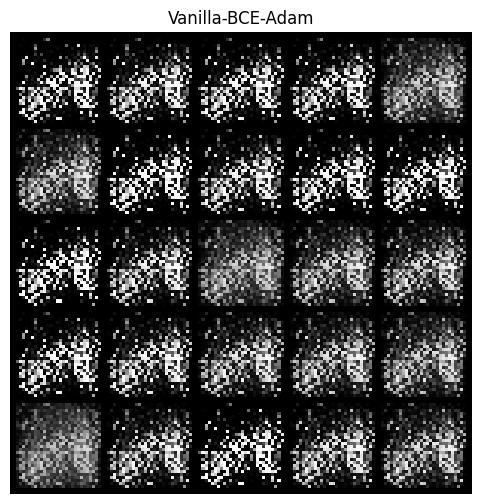

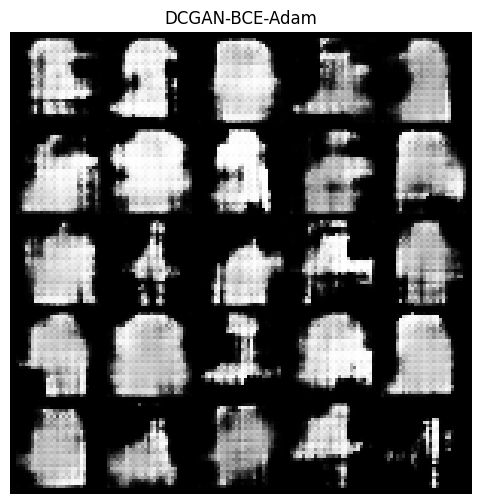

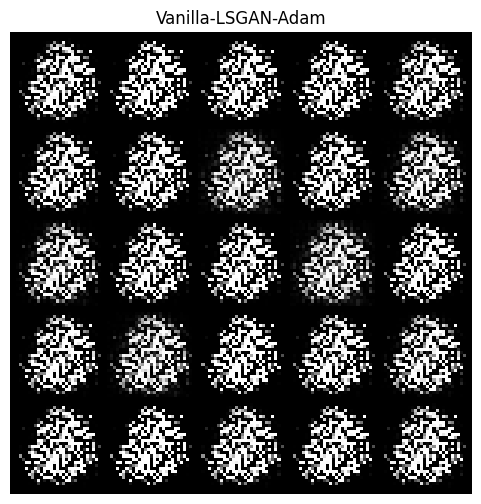

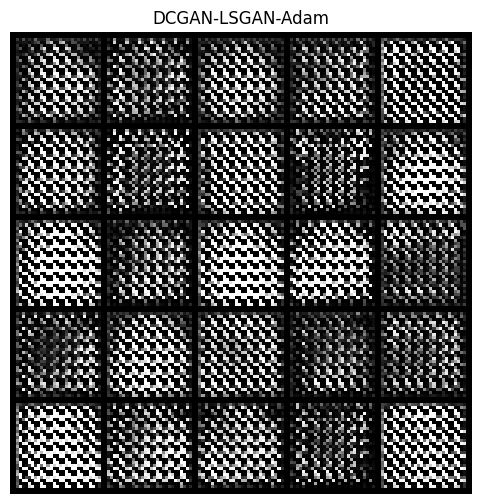

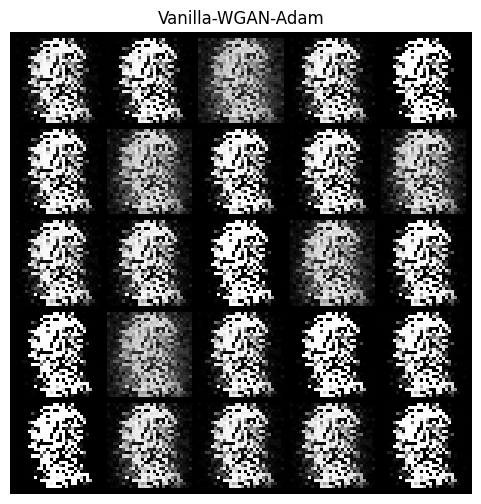

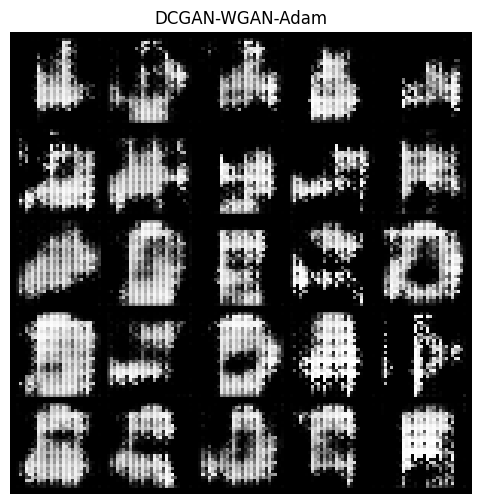

In [ ]:
# Loss Function Comparison

for name in trained_generators:

    if "Adam" in name:

        generate_samples(

            trained_generators[name],

            title=name

        )

### Add Optimizer Comparison Plot

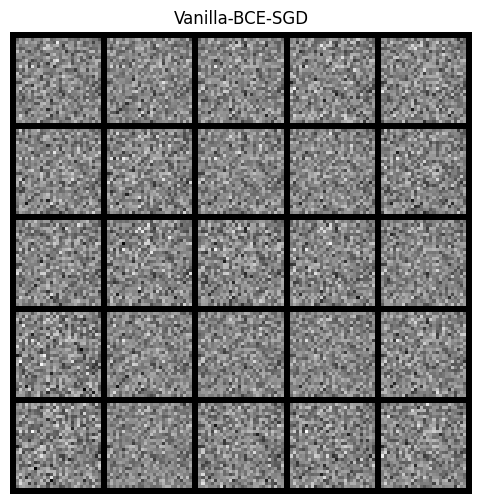

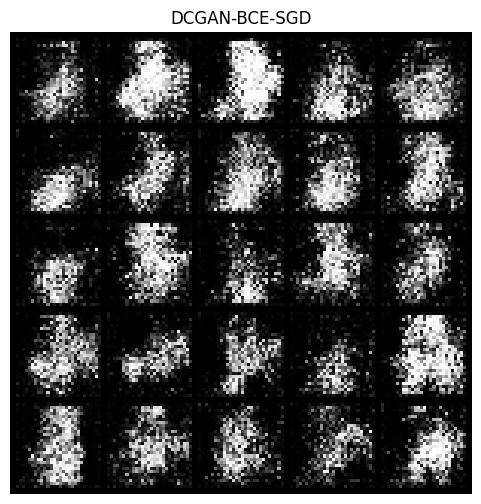

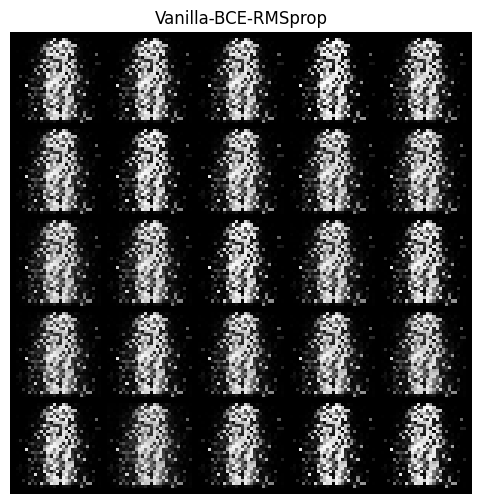

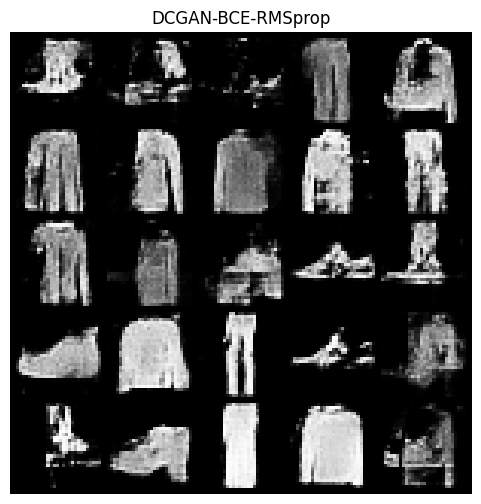

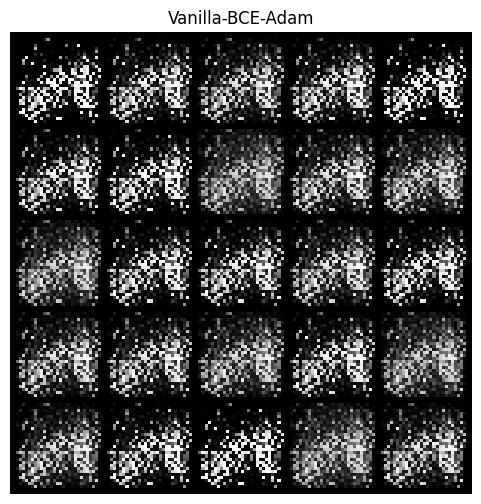

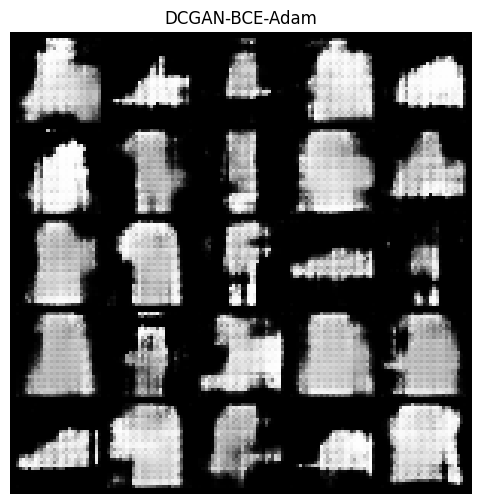

In [ ]:
# Optimizer Comparison

for name in trained_generators:

    if "BCE" in name:

        generate_samples(

            trained_generators[name],

            title=name

        )